In [28]:
# helper functions
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

INK, BLUE, RED, GREY = '#1f2933', '#2a6f97', '#c8553d', '#8a9ba8'

In [16]:
# original dataset
df = pd.read_csv("/home/ntorquet/Desktop/Visualization/Infovis2627-Group9/training_dataset/CleanDataset/accidents_bcn_2019_2025.csv")

In [17]:
# First we have to explore the diff fields
print(df.shape)
df.head(3).T

(54954, 29)


,0,1,2
numero_expedient,2019S000001,2019S000002,2019S000003
codi_districte,5.0,9.0,10.0
nom_districte,Sarrià-Sant Gervasi,Sant Andreu,Sant Martí
nom_barri,Sant Gervasi - Galvany,el Congrés i els Indians,el Parc i la Llacuna del Poblenou
nom_carrer,Diagonal / Augusta,Felip II / Congrés Eucarístic,Pallars
nk_any,2019,2019,2019
mes_any,1,1,1
nom_mes,Gener,Gener,Gener
dia_mes,1,1,1
hora_dia,1,4,5


## Data types table

In [18]:
data_types = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isnull().sum(),
        "unique": df.nunique(),
        "example": df.iloc[0],
    }
)
data_types

,dtype,missing,unique,example
numero_expedient,object,0,54928,2019S000001
codi_districte,float64,232,10,5.0
nom_districte,object,232,10,Sarrià-Sant Gervasi
nom_barri,object,232,74,Sant Gervasi - Galvany
nom_carrer,object,1,6030,Diagonal / Augusta
nk_any,int64,0,7,2019
mes_any,int64,0,12,1
nom_mes,object,0,12,Gener
dia_mes,int64,0,31,1
hora_dia,int64,0,24,1


| Field | Type | Order | Zero / distance | Domain / range in data | Unit, precision |
|---|---|---|---|---|---|
| `numero_expedient` | categorical, nominal (identifier) | none | - | other | 2019S000001… | - |
| `codi_districte` | categorical, nominal (numeric code, not a magnitude) | none | - | geographic | 1-10 | code |
| `nom_districte` | categorical, nominal | none | - | geographic | 10 districts | - |
| `nom_barri` | categorical, nominal, hierarchy | none | - | geographic | 74 neighbourhoods | - |
| `nom_carrer` | categorical, nominal | none | - | geographic | 6,030 streets/intersections | - |
| `nk_any` | numerical, discrete, interval | sequential | by convention | temporal | 2019-2025 | year |
| `mes_any`, `nom_mes` | categorical, ordinal | cyclic | - | temporal | 1-12 | month |
| `dia_mes` | numerical, discrete, interval | sequential | by convention | temporal | 1-31 | day |
| `hora_dia` | numerical, discrete, interval | cyclic (23h is next to 0h) | by convention | temporal | 0-23 | hour (no minutes) |
| `dia_semana`, `descripcio_dia_setmana` | categorical, ordinal | cyclic | - | temporal | 7 values (English / Catalan, redundant) | day |
| `descripcio_torn`, `franja_horaria` | categorical, ordinal | cyclic | - | temporal | 3 shifts / 4 six-hour bands | - |
| `fecha` | date | sequential | by convention | temporal | 2019-01-01 … 2025-12-31 | day |
| `fin_de_semana`, `es_causa_vianant`, `accidente_con_victimas` | categorical, nominal (binary) | none | - | other | 2 values | - |
| `descripcio_causa_vianant` | categorical, nominal | none | - | other | 8 values | - |
| `gravedad` (derived) | categorical, ordinal | sequential (Leve < Grave < Mortal) | - | other | 3 values | - |
| `numero_morts`, `numero_lesionats_lleus`, `numero_lesionats_greus`, `numero_victimes`, `total_lesionados` | numerical, discrete, ratio | sequential | real zero | other | deaths 0-1, minor 0-49, serious 0-6, victims 0-53 | people |
| `numero_vehicles_implicats` | numerical, discrete, ratio | sequential | real zero | other | 0-18 | vehicles |
| `longitud`, `latitud` | numerical, continuous, interval | none (position) | by convention | geographic | 2.06-2.22 E, 41.32-41.47 N | degrees, street-level |
| `fichero_origen` | categorical, nominal | none | - | other | one file per year | - |

In [19]:
num_cols = [
    "numero_morts",
    "numero_lesionats_lleus",
    "numero_lesionats_greus",
    "numero_victimes",
    "total_lesionados",
    "numero_vehicles_implicats",
    "hora_dia",
]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
numero_morts,54954.0,0.002093,0.045698,0.0,0.0,0.0,0.0,1.0
numero_lesionats_lleus,54954.0,1.118645,0.789220,0.0,1.0,1.0,1.0,49.0
numero_lesionats_greus,54954.0,0.025803,0.170389,0.0,0.0,0.0,0.0,6.0
numero_victimes,54954.0,1.146541,0.787078,0.0,1.0,1.0,1.0,53.0
total_lesionados,54954.0,1.144448,0.787545,0.0,1.0,1.0,1.0,53.0
numero_vehicles_implicats,54954.0,1.869545,0.714496,0.0,2.0,2.0,2.0,18.0
hora_dia,54954.0,13.791735,5.312304,0.0,10.0,14.0,18.0,23.0


In [20]:
for c in ['nom_districte','gravedad','descripcio_torn','franja_horaria','fin_de_semana',
          'descripcio_causa_vianant','es_causa_vianant']:
    print(df[c].value_counts(dropna=False).to_string(), '\n')

nom_districte
Eixample               15080
Sant Martí              6872
Sants-Montjuïc          6168
Sarrià-Sant Gervasi     5864
Horta-Guinardó          4131
Les Corts               3829
Sant Andreu             3769
Nou Barris              3217
Ciutat Vella            3003
Gràcia                  2789
NaN                      232 

gravedad
Leve      53516
Grave      1323
Mortal      115 

descripcio_torn
Tarda    27333
Matí     21224
Nit       6397 

franja_horaria
Tarde (12-18h)        21862
Noche (18-24h)        15389
Manana (06-12h)       14208
Madrugada (00-06h)     3495 

fin_de_semana
Laborable        43794
Fin de semana    11160 

descripcio_causa_vianant
No és causa del vianant            31266
No es causa del vianant            14285
Desconegut                          5887
Desobeir el senyal del semàfor      1319
Creuar per fora pas de vianants     1108
Altres                               718
Transitar a peu per la calçada       339
Desobeir altres senyals               32

### Data quality

In [21]:
# Missing values
miss = df.isna().sum()
print(miss[miss > 0], "\n")
print(
    "Rows without district:",
    df.nom_districte.isna().sum(),
    ", which also without coordinates:",
    df[df.nom_districte.isna()].latitud.isna().sum(),
)
print(
    df[df.nom_districte.isna()].nk_any.value_counts().sort_index().to_dict(),
)

codi_districte    232
nom_districte     232
nom_barri         232
nom_carrer          1
longitud           42
latitud            42
dtype: int64 

Rows without district: 232 , which also without coordinates: 42
{2019: 19, 2020: 18, 2021: 26, 2022: 79, 2023: 90}


In [22]:
# Duplicates
dup = df[df.numero_expedient.duplicated(keep=False)].sort_values('numero_expedient')
cols_that_differ = {c for k, g in dup.groupby('numero_expedient') for c in df.columns if g[c].astype(str).nunique() > 1}
print('repeated case numbers:', dup.numero_expedient.nunique())
print('columns that differ between repeated rows:', cols_that_differ)
print('unique accidents:', df.numero_expedient.nunique())

repeated case numbers: 26
columns that differ between repeated rows: {'descripcio_causa_vianant'}
unique accidents: 54928


In [23]:
# Inconsistencies in the sums of overalls
f = pd.to_datetime(df.fecha)
checks = {
    "date vs year/month/day": (
        (f.dt.year != df.nk_any) | (f.dt.month != df.mes_any) | (f.dt.day != df.dia_mes)
    ).sum(),
    "weekday name vs date": (f.dt.day_name() != df.dia_semana).sum(),
    "victims != deaths+minor+serious": (
        df.numero_victimes
        != df.numero_morts + df.numero_lesionats_lleus + df.numero_lesionats_greus
    ).sum(),
    "total_lesionados != minor+serious": (
        df.total_lesionados != df.numero_lesionats_lleus + df.numero_lesionats_greus
    ).sum(),
    "case-number year != year": (
        df.numero_expedient.str[:4].astype(int) != df.nk_any
    ).sum(),
    "accidents with 0 vehicles": (df.numero_vehicles_implicats == 0).sum(),
}
pd.Series(checks, name="rows failing")

date vs year/month/day                0
weekday name vs date                  0
victims != deaths+minor+serious       0
total_lesionados != minor+serious     0
case-number year != year              2
accidents with 0 vehicles            36
Name: rows failing, dtype: int64

In [24]:
# Errors with spellings
print(df.descripcio_causa_vianant.value_counts().head(3))
expected = np.where(df.numero_morts > 0, 'Mortal', np.where(df.numero_lesionats_greus > 0, 'Grave', 'Leve'))
print('\nrows where gravedad disagrees with the rule:', (expected != df.gravedad).sum())

descripcio_causa_vianant
No és causa del vianant    31266
No es causa del vianant    14285
Desconegut                  5887
Name: count, dtype: int64

rows where gravedad disagrees with the rule: 0


### Zeros are real or blank converted to zeros (by convention)

The `cleaning.txt` file said that blanks in 2024 and 2025 were converted to zero. A real 0 means taht nobody was injured. A converted blank means not recorded. After cleaning, they look identical. We can only watch for suspicious behaviour.

In [25]:
z = (
    df.assign(
        no_minor=df.numero_lesionats_lleus == 0, no_victims=df.numero_victimes == 0
    )
    .groupby("nk_any")[["no_minor", "no_victims"]]
    .mean()
    .mul(100)
    .round(1)
)
z.columns = ["% accidents with 0 minor injured", "% accidents with 0 victims"]
z

,% accidents with 0 minor injured,% accidents with 0 victims
nk_any,,
2019,9.2,7.7
2020,10.4,8.7
2021,10.1,8.5
2022,11.7,9.8
2023,13.3,11.1
2024,13.4,10.8
2025,14.1,11.5


We see that the % of accidents with no victims rises. But cannot tell if this is the real trend or unrecorded blanks. 2024-2025 should be studied taking into account this caveat.

### Apply the cleaning following `cleaning.txt` instructions

In [26]:
d = df.copy()
d["fecha"] = pd.to_datetime(d.fecha)
# text fields: strip spaces, harmonize spelling
for c in d.select_dtypes(["object", "string"]).columns:
    d[c] = d[c].str.strip()
d["descripcio_causa_vianant"] = d.descripcio_causa_vianant.str.replace("No és", "No es")
# ordered categoricals
d["franja_horaria"] = pd.Categorical(
    d.franja_horaria,
    ["Madrugada (00-06h)", "Manana (06-12h)", "Tarde (12-18h)", "Noche (18-24h)"],
    ordered=True,
)
d["gravedad"] = pd.Categorical(d.gravedad, ["Leve", "Grave", "Mortal"], ordered=True)
d["dia_semana"] = pd.Categorical(
    d.dia_semana,
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
d["grave_o_mortal"] = d.gravedad != "Leve"
print(d.descripcio_causa_vianant.value_counts().to_string())

descripcio_causa_vianant
No es causa del vianant            45551
Desconegut                          5887
Desobeir el senyal del semàfor      1319
Creuar per fora pas de vianants     1108
Altres                               718
Transitar a peu per la calçada       339
Desobeir altres senyals               32


### Study the distribution

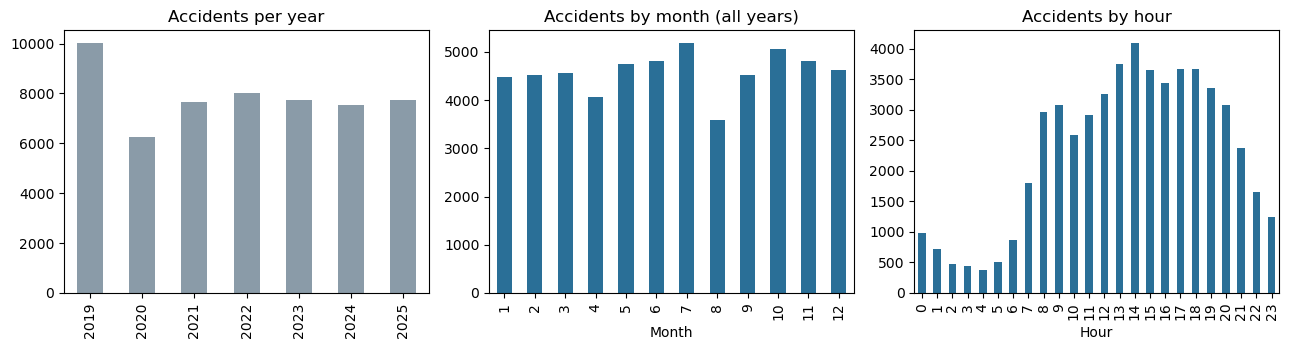

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
d.groupby("nk_any").size().plot.bar(ax=axs[0], color=GREY)
axs[0].set_title("Accidents per year")
axs[0].set_xlabel("")
d.groupby("mes_any").size().plot.bar(ax=axs[1], color=BLUE)
axs[1].set_title("Accidents by month (all years)")
axs[1].set_xlabel("Month")
d.groupby("hora_dia").size().plot.bar(ax=axs[2], color=BLUE)
axs[2].set_title("Accidents by hour")
axs[2].set_xlabel("Hour")
plt.tight_layout()
plt.show()

- 2020 behaviour is due to the pandemic; April 2020 has only 104 accidents
- August is the lowest month; people are on vacations, not in Barcelona
- The hour profile has a peak in the early afternoon (14:00), a second peak around 17-18h

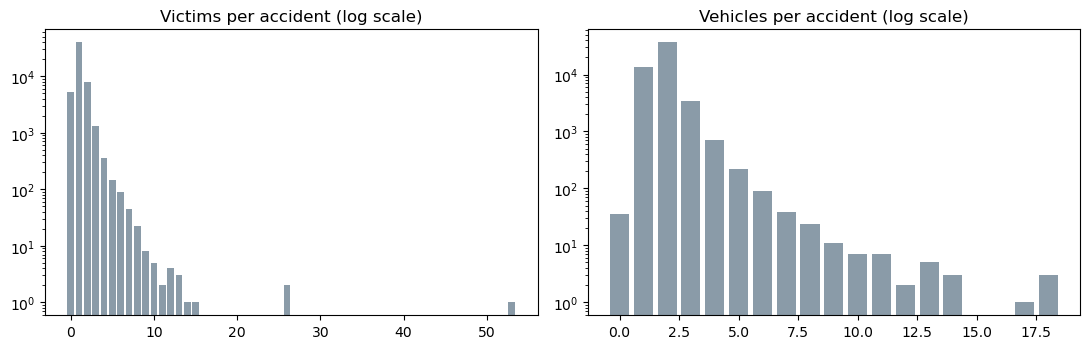

,fecha,numero_victimes,numero_vehicles_implicats,gravedad
48413,2025-03-03,53,3,Grave
4813,2019-06-20,26,4,Grave
35502,2023-06-15,26,2,Grave
43892,2024-07-21,15,2,Leve


In [30]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, c, t in [
    (axs[0], "numero_victimes", "Victims per accident"),
    (axs[1], "numero_vehicles_implicats", "Vehicles per accident"),
]:
    vc = d[c].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=GREY)
    ax.set_yscale("log")
    ax.set_title(t + " (log scale)")
plt.tight_layout()
plt.show()
d.nlargest(4, "numero_victimes")[
    ["fecha", "numero_victimes", "numero_vehicles_implicats", "gravedad"]
]

Both distributions are heavy tailed. Almost all accidents have 1-2 victims and 1-2 vehicles. There're outliers (53 victims on 3 vehicles) but they look like real event. So we'll use a log scale or cap the axis in the plots.

gravedad
Leve      97.38
Grave      2.41
Mortal     0.21


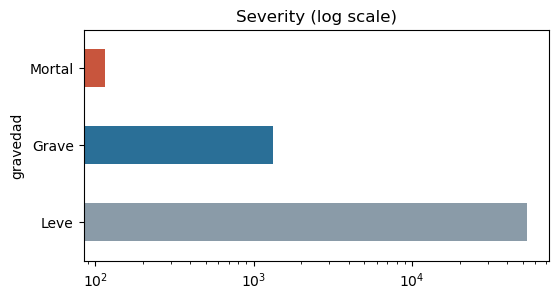

In [31]:
sev = d.gravedad.value_counts(normalize=True).mul(100).round(2); print(sev.to_string())
fig, ax = plt.subplots(figsize=(6, 3)); d.gravedad.value_counts().plot.barh(ax=ax, color=[GREY, BLUE, RED][:3]); ax.set_xscale('log'); ax.set_title('Severity (log scale)'); plt.show()

Severity is very imbalanced.

### Relationships

In [33]:
yr = d.groupby("nk_any").agg(
    accidents=("gravedad", "size"),
    grave=("gravedad", lambda s: (s == "Grave").sum()),
    mortal=("gravedad", lambda s: (s == "Mortal").sum()),
)
yr["grave_pct"] = (yr.grave / yr.accidents * 100).round(2)
yr

,accidents,grave,mortal,grave_pct
nk_any,,,,
2019,10027,185,22,1.85
2020,6268,126,14,2.01
2021,7659,152,12,1.98
2022,7999,169,24,2.11
2023,7724,212,21,2.74
2024,7536,238,11,3.16
2025,7741,241,11,3.11


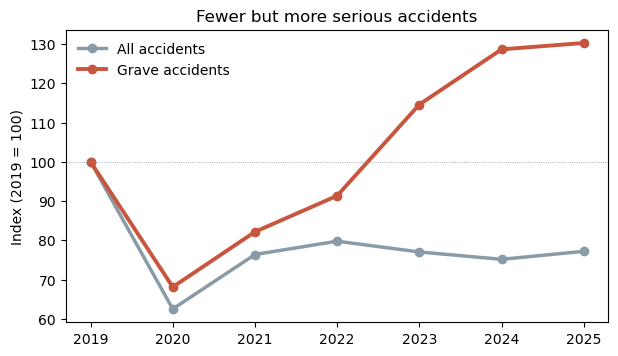

        accidents  grave
nk_any                  
2019        100.0  100.0
2020         62.5   68.1
2021         76.4   82.2
2022         79.8   91.4
2023         77.0  114.6
2024         75.2  128.6
2025         77.2  130.3


In [34]:
idx = yr[["accidents", "grave"]] / yr[["accidents", "grave"]].loc[2019] * 100
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(idx.index, idx.accidents, color=GREY, lw=2.5, marker="o", label="All accidents")
ax.plot(idx.index, idx.grave, color=RED, lw=2.8, marker="o", label="Grave accidents")
ax.axhline(100, color=GREY, lw=0.6, ls=":")
ax.set_ylabel("Index (2019 = 100)")
ax.legend(frameon=False)
ax.set_title("Fewer but more serious accidents")
plt.show()
print(idx.round(1))

After 2020, the total number of accidents are below 2019 levels, but severe accidents with seriously injured people are higher, about 30% above 2019.

In [36]:
# Severity by time of day and weekend
by_hour = (
    d.groupby("franja_horaria", observed=True).grave_o_mortal.mean().mul(100).round(2)
)
by_we = d.groupby("fin_de_semana").grave_o_mortal.mean().mul(100).round(2)
by_ped = d.groupby("es_causa_vianant").grave_o_mortal.mean().mul(100).round(2)
print("% greu/mortal per franja horaria:\n", by_hour.to_string(), "\n")
print("% greu/mortal per cap de setmana:\n", by_we.to_string(), "\n")
print("% greu/mortal per causa de vianant:\n", by_ped.to_string(), "\n")
print(
    f"pedestrian share, all accidents: {d.es_causa_vianant.mean() * 100:.1f}%; in greu/mortal: {d[d.grave_o_mortal].es_causa_vianant.mean() * 100:.1f}%"
)

% greu/mortal per franja horaria:
 franja_horaria
Madrugada (00-06h)    4.15
Manana (06-12h)       2.55
Tarde (12-18h)        2.18
Noche (18-24h)        2.94 

% greu/mortal per cap de setmana:
 fin_de_semana
Fin de semana    2.99
Laborable        2.52 

% greu/mortal per causa de vianant:
 es_causa_vianant
False    2.37
True     3.80 

pedestrian share, all accidents: 17.1%; in greu/mortal: 24.8%


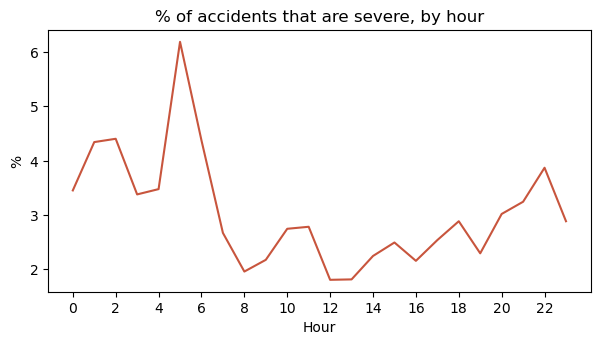

In [38]:
sb = d.groupby("hora_dia").grave_o_mortal.mean() * 100
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sb.index, sb.values, color=RED)
ax.set_xticks(range(0, 24, 2))
ax.set_title("% of accidents that are severe, by hour")
ax.set_xlabel("Hour")
ax.set_ylabel("%")
plt.show()

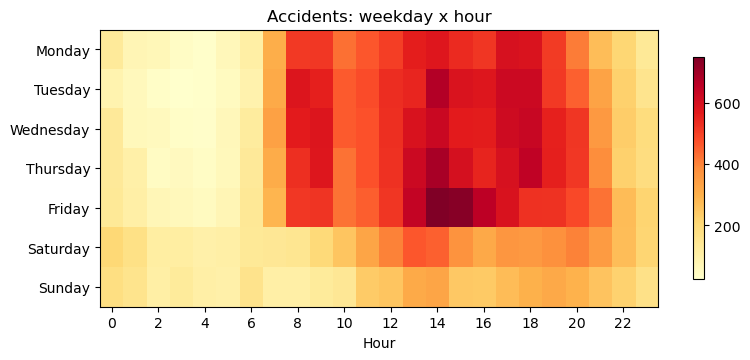

In [39]:
hm = d.groupby(["dia_semana", "hora_dia"], observed=True).size().unstack()
fig, ax = plt.subplots(figsize=(9, 3.6))
im = ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(7))
ax.set_yticklabels(hm.index)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel("Hour")
ax.set_title("Accidents: weekday x hour")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

In [40]:
dist = (
    d.dropna(subset=["nom_districte"])
    .groupby("nom_districte")
    .agg(
        accidents=("gravedad", "size"),
        serious_pct=("grave_o_mortal", lambda s: round(s.mean() * 100, 2)),
    )
    .sort_values("accidents", ascending=False)
)
dist["share_pct"] = (dist.accidents / dist.accidents.sum() * 100).round(1)
dist

,accidents,serious_pct,share_pct
nom_districte,,,
Eixample,15080,2.59,27.6
Sant Martí,6872,2.66,12.6
Sants-Montjuïc,6168,2.68,11.3
Sarrià-Sant Gervasi,5864,2.63,10.7
Horta-Guinardó,4131,3.41,7.5
Les Corts,3829,3.06,7.0
Sant Andreu,3769,1.96,6.9
Nou Barris,3217,2.46,5.9
Ciutat Vella,3003,2.53,5.5


We see that Eixample has 27.6% of the accidents, but these are raw conints as there's no population or traffic denominator. They say little about relative risk.
Serious accidents are higher in Horta-Guinardó and Les Corts; lowest in Sant Andreu and Gràcia.

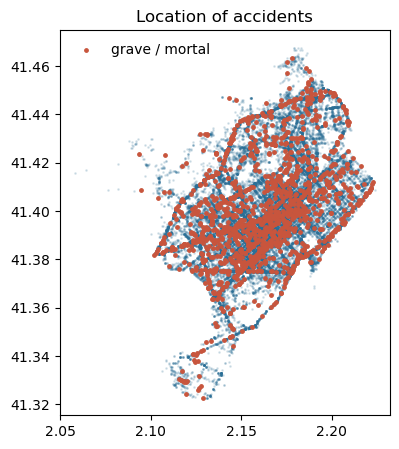

In [41]:
g = d.dropna(subset=["latitud"])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(g.longitud, g.latitud, s=1, alpha=0.15, color=BLUE)
s = g[g.grave_o_mortal]
ax.scatter(s.longitud, s.latitud, s=6, color=RED, label="grave / mortal")
ax.set_aspect(1 / np.cos(np.radians(41.4)))
ax.legend(frameon=False)
ax.set_title("Location of accidents")
plt.show()

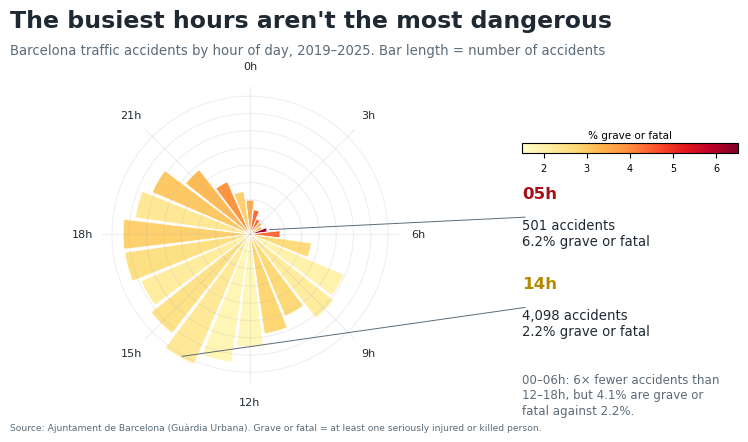

In [44]:
from matplotlib import cm, colors

df['serious'] = df.gravedad != 'Leve'
h = df.groupby("hora_dia").agg(n=("serious", "size"), p=("serious", "mean"))
h["p"] *= 100

INK, MUTED = "#1f2933", "#5b6b78"
norm, cmap = colors.Normalize(1.5, 6.5), cm.YlOrRd

fig = plt.figure(figsize=(8, 4.5), dpi=100)

ax = fig.add_axes([0.05, 0.13, 0.56, 0.66], projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

theta = np.arange(24) * 2 * np.pi / 24
ax.bar(
    theta,
    h.n,
    width=2 * np.pi / 24 * 0.9,
    color=[cmap(norm(v)) for v in h.p],
    edgecolor="white",
    lw=0.5,
)

ax.set_xticks(theta[::3])
ax.set_xticklabels([f"{i}h" for i in range(0, 24, 3)], fontsize=8, color=INK)
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)
ax.grid(alpha=0.2)

for hour, y_fig in [(5, 0.50), (14, 0.30)]:
    ax.annotate(
        "",
        xy=(theta[hour], h.n[hour]),
        xytext=(0.66, y_fig),
        xycoords="data",
        textcoords="figure fraction",
        arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.7),
    )

fig.text(0.67, 0.54, "05h", fontsize=12, fontweight="bold", color="#a50f15")
fig.text(
    0.67,
    0.495,
    f"{h.n[5]:,} accidents\n{h.p[5]:.1f}% grave or fatal",
    fontsize=9.5,
    color=INK,
    va="top",
)
fig.text(0.67, 0.34, "14h", fontsize=12, fontweight="bold", color="#b58a00")
fig.text(
    0.67,
    0.295,
    f"{h.n[14]:,} accidents\n{h.p[14]:.1f}% grave or fatal",
    fontsize=9.5,
    color=INK,
    va="top",
)

night = df[df.hora_dia < 6]
aftn = df[df.hora_dia.between(12, 17)]
fig.text(
    0.67,
    0.15,
    f"00–06h: {len(aftn) / len(night):.0f}× fewer accidents than\n"
    f"12–18h, but {night.serious.mean() * 100:.1f}% are grave or\n"
    f"fatal against {aftn.serious.mean() * 100:.1f}%.",
    fontsize=8.5,
    color=MUTED,
    va="top",
)

cax = fig.add_axes([0.67, 0.64, 0.27, 0.022])
cb = fig.colorbar(cm.ScalarMappable(norm, cmap), cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=7)
cb.set_label("% grave or fatal", fontsize=7.5)
cb.ax.xaxis.set_label_position("top")

fig.text(
    0.03,
    0.92,
    "The busiest hours aren't the most dangerous",
    fontsize=17,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.03,
    0.86,
    "Barcelona traffic accidents by hour of day, 2019–2025. "
    "Bar length = number of accidents",
    fontsize=9.5,
    color=MUTED,
)
fig.text(
    0.03,
    0.025,
    "Source: Ajuntament de Barcelona (Guàrdia Urbana). "
    "Grave or fatal = at least one seriously injured or killed person.",
    fontsize=6.6,
    color=MUTED,
)

fig.savefig("task01_chart.png", dpi=100)
plt.show()